# Predicting Airline Satisfaction
## Last public score: .95860

## Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv("playground-series-s6e10/train.csv")
test = pd.read_csv("playground-series-s6e10/test.csv")
sample_submission = pd.read_csv("playground-series-s6e10/sample_submission.csv")

## EDA

In [2]:
display(train.shape, test.shape)
display(train.head())
display(train.dtypes)
display(train.describe(include="all").T)
display(train.isna().sum())
display(test.isna().sum())
display(train["satisfaction"].value_counts(normalize=True))

cat_cols = train.select_dtypes(include=["object", "string", "bool"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "satisfaction"]
for col in cat_cols:
    display(col, train[col].value_counts())

(699635, 23)

(299844, 22)

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,...,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,1,56,651,5,5,5,5,5,4,4,...,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,2,31,1371,3,4,2,5,3,3,3,...,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
3,3,10,1616,3,5,3,3,3,3,3,...,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
4,4,23,481,3,4,3,4,5,3,5,...,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False


id                                     int64
Age                                    int64
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
Gender                                   str
Customer Type                            str
Type of Travel                           str
Class                                    str
satisfacti

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,699635.0,NaN,NaN,NaN,349817.0,201967.37213,0.0,174908.5,349817.0,524725.5,699634.0
Age,699635.0,NaN,NaN,NaN,39.001928,13.800943,7.0,27.0,40.0,50.0,85.0
Flight Distance,699635.0,NaN,NaN,NaN,1353.778702,954.422566,67.0,631.0,954.0,1814.0,4983.0
Inflight wifi service,699635.0,NaN,NaN,NaN,2.778722,1.280419,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,699635.0,NaN,NaN,NaN,3.15621,1.47539,0.0,2.0,3.0,4.0,5.0
Ease of Online booking,699635.0,NaN,NaN,NaN,2.81324,1.32955,0.0,2.0,3.0,4.0,5.0
Gate location,699635.0,NaN,NaN,NaN,3.013734,1.254014,0.0,2.0,3.0,4.0,5.0
Food and drink,699635.0,NaN,NaN,NaN,3.265644,1.300202,0.0,2.0,3.0,4.0,5.0
Online boarding,699635.0,NaN,NaN,NaN,3.364156,1.288538,0.0,2.0,4.0,4.0,5.0
Seat comfort,699635.0,NaN,NaN,NaN,3.56895,1.275333,0.0,3.0,4.0,5.0,5.0


...

Customer Type
Loyal Customer       576990
disloyal Customer    122645
Name: count, dtype: int64

'Type of Travel'

Type of Travel
Business travel    497441
Personal Travel    202194
Name: count, dtype: int64

'Class'

Class
Business    342212
Eco         327404
Eco Plus     30019
Name: count, dtype: int64

## Feature Distributions

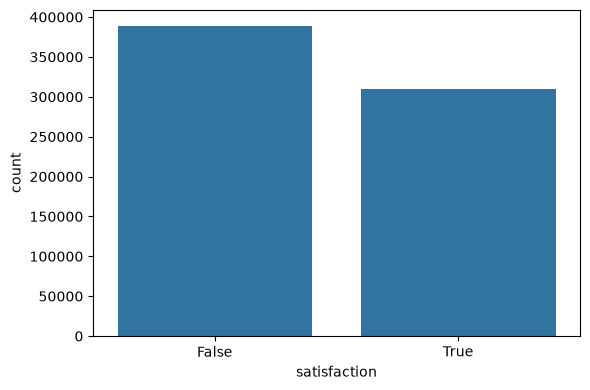

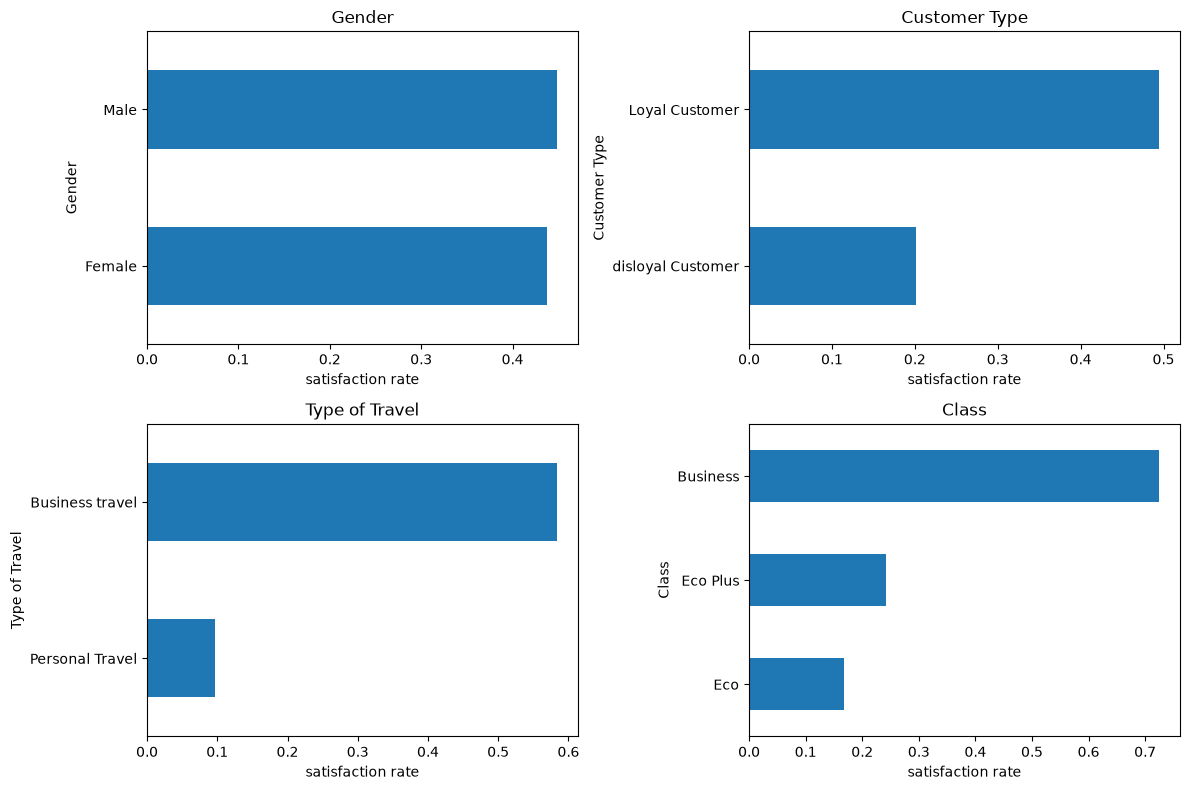

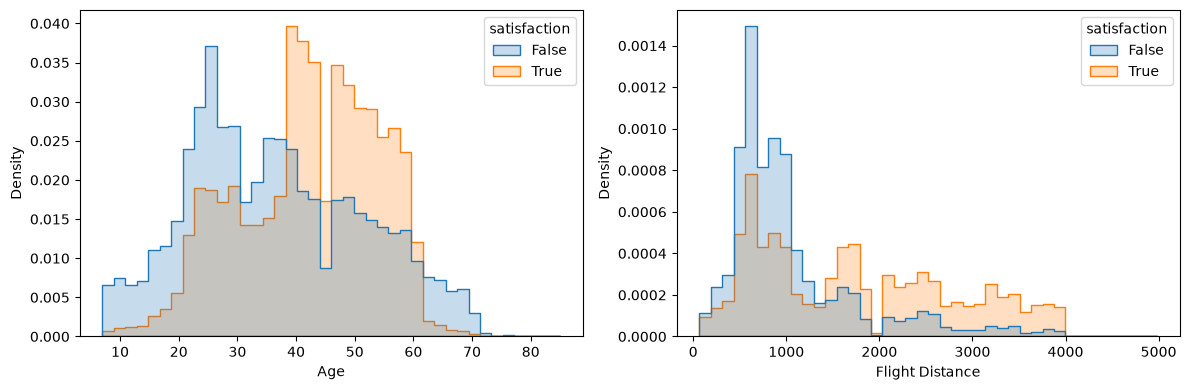

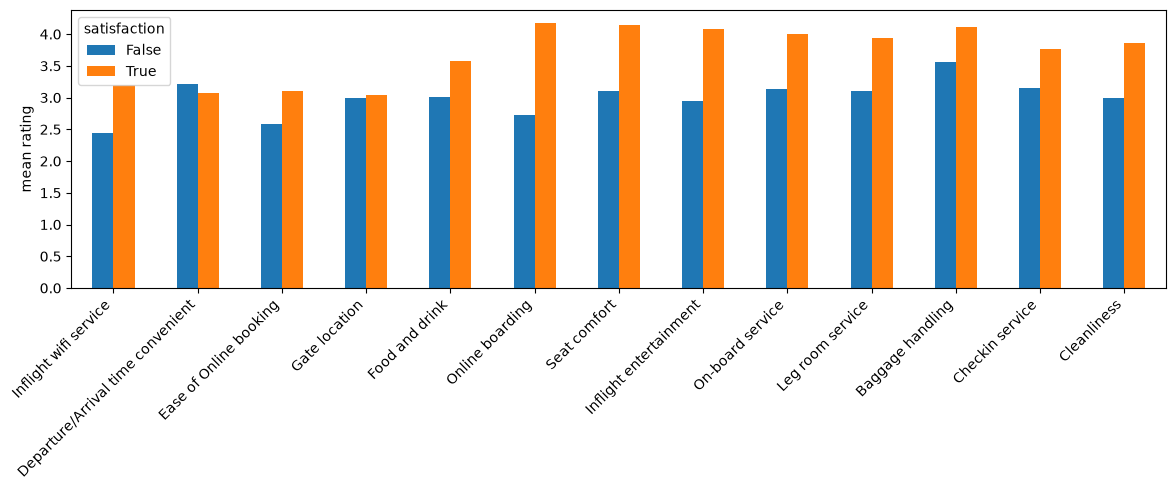

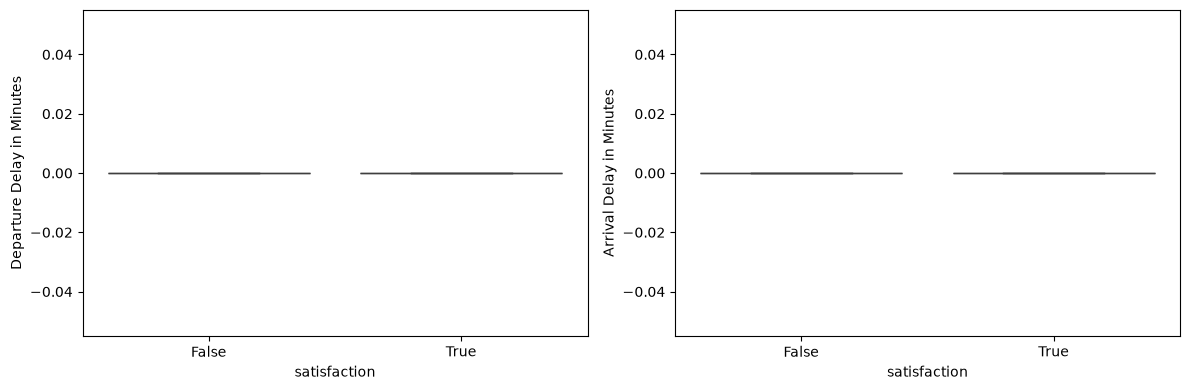

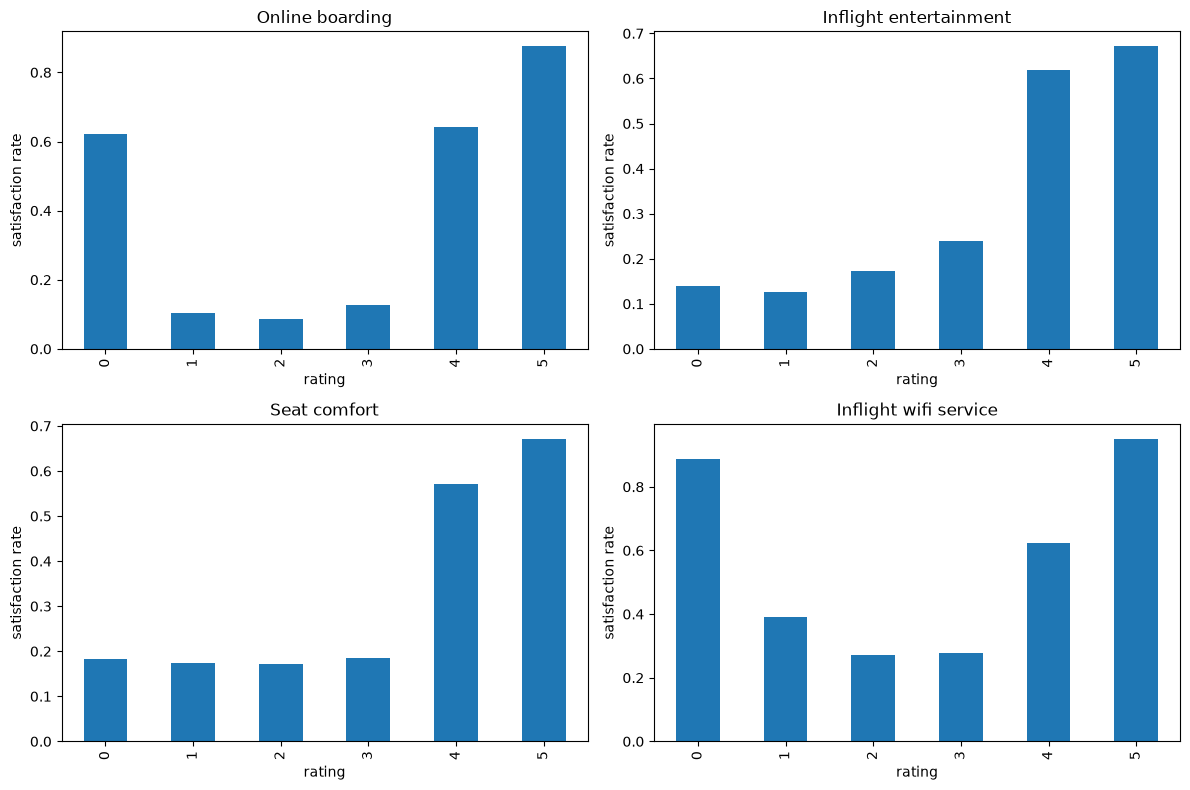

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=train, x="satisfaction", ax=ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = train.groupby(col, observed=True)["satisfaction"].mean().sort_values()
    rate.plot(kind="barh", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("satisfaction rate")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Age", "Flight Distance"]):
    sns.histplot(data=train, x=col, hue="satisfaction", bins=40, element="step", common_norm=False, stat="density", ax=ax)
plt.tight_layout()
plt.show()

rating_cols = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Cleanliness",
]

rating_means = train.groupby("satisfaction", observed=True)[rating_cols].mean().T
rating_means.plot(kind="bar", figsize=(12, 5))
plt.ylabel("mean rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["Departure Delay in Minutes", "Arrival Delay in Minutes"]):
    sns.boxplot(data=train, x="satisfaction", y=col, ax=ax, showfliers=False)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["Online boarding", "Inflight entertainment", "Seat comfort", "Inflight wifi service"]):
    rate = train.groupby(col, observed=True)["satisfaction"].mean()
    rate.plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("satisfaction rate")
    ax.set_xlabel("rating")
plt.tight_layout()
plt.show()

## Correlation Matrix

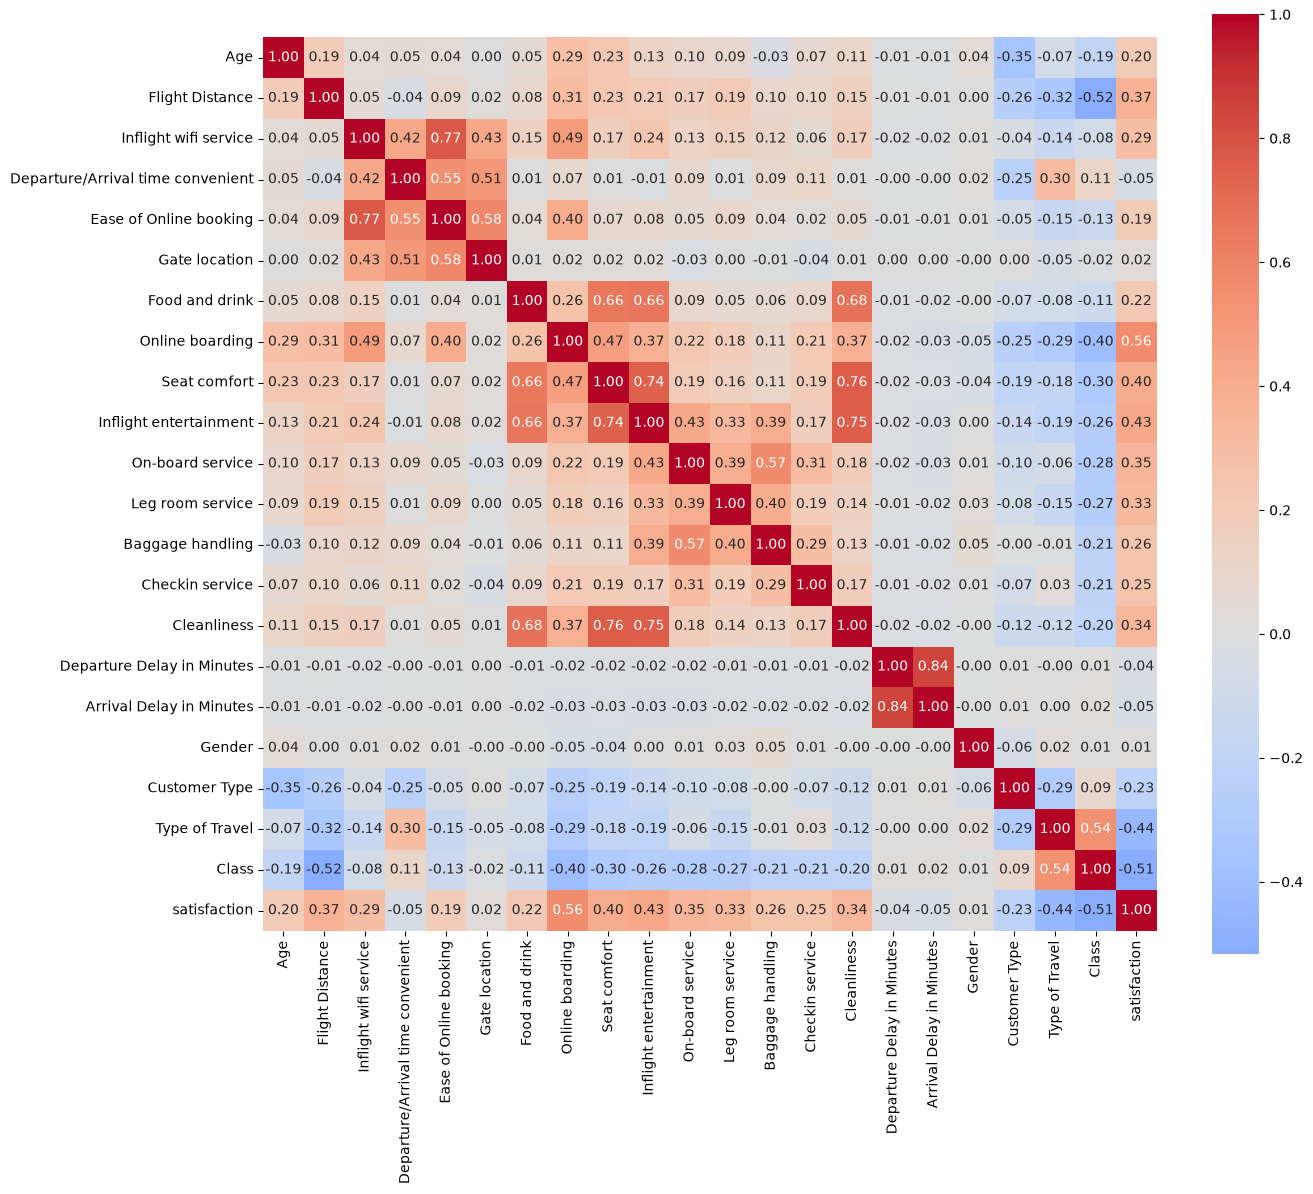

satisfaction                         1.000000
Online boarding                      0.559583
Inflight entertainment               0.430755
Seat comfort                         0.401488
Flight Distance                      0.370038
On-board service                     0.346618
Cleanliness                          0.338853
Leg room service                     0.330116
Inflight wifi service                0.291275
Baggage handling                     0.258118
Checkin service                      0.249799
Food and drink                       0.218058
Age                                  0.202708
Ease of Online booking               0.190878
Gate location                        0.022834
Gender                               0.011169
Departure Delay in Minutes          -0.035815
Departure/Arrival time convenient   -0.049185
Arrival Delay in Minutes            -0.051641
Customer Type                       -0.225161
Type of Travel                      -0.444418
Class                             

In [4]:
corr_df = train.drop(columns=["id"]).copy()
corr_df["satisfaction"] = corr_df["satisfaction"].astype(int)
for col in cat_cols:
    corr_df[col] = corr_df[col].astype("category").cat.codes

corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.tight_layout()
plt.show()

display(corr["satisfaction"].sort_values(ascending=False))

## Preprocessing

In [5]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize
from scipy.special import expit, logit
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

TARGET = "satisfaction"
ID_COL = "id"
CAT_COLS = ["Gender", "Customer Type", "Type of Travel", "Class"]
RATING_COLS = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Cleanliness",
]
INTER_COLS = ["travel_class", "cust_travel", "cust_class"]
TE_COLS = CAT_COLS + INTER_COLS
FEATURE_COLS = [c for c in train.columns if c not in [ID_COL, TARGET]]


def prepare_features(df, inter=False, ratings_as_cat=False, source=0):
    out = df[FEATURE_COLS].copy()
    out["Arrival Delay in Minutes"] = out["Arrival Delay in Minutes"].fillna(
        out["Departure Delay in Minutes"]
    )
    out["log_dist"] = np.log1p(out["Flight Distance"].astype(float))
    out["senior_biz"] = (
        (out["Age"] >= 65) & (out["Class"].astype(str) == "Business")
    ).astype(np.int8)
    out["is_original"] = np.int8(source)
    cat_cols = list(CAT_COLS)
    if inter:
        out["travel_class"] = (
            out["Type of Travel"].astype(str) + "|" + out["Class"].astype(str)
        ).astype("category")
        out["cust_travel"] = (
            out["Customer Type"].astype(str) + "|" + out["Type of Travel"].astype(str)
        ).astype("category")
        out["cust_class"] = (
            out["Customer Type"].astype(str) + "|" + out["Class"].astype(str)
        ).astype("category")
        cat_cols = cat_cols + INTER_COLS
    if ratings_as_cat:
        cat_cols = cat_cols + RATING_COLS
    for col in cat_cols:
        out[col] = out[col].astype("category")
    return out, cat_cols


def add_target_encoding(X_train, X_test, y_train, cols, folds):
    X_tr = X_train.copy()
    X_te = X_test.copy()
    global_mean = float(y_train.mean())
    for col in cols:
        oof = np.zeros(len(X_train))
        test_acc = np.zeros(len(X_test))
        keys_tr = X_train[col].astype(str)
        keys_te = X_test[col].astype(str)
        for tr_idx, va_idx in folds:
            tmp = pd.DataFrame({"k": keys_tr.iloc[tr_idx].values, "y": y_train.iloc[tr_idx].values})
            means = tmp.groupby("k")["y"].mean()
            oof[va_idx] = keys_tr.iloc[va_idx].map(means).fillna(global_mean).astype(float).values
            test_acc += keys_te.map(means).fillna(global_mean).astype(float).values / len(folds)
        X_tr[col + "_te"] = oof
        X_te[col + "_te"] = test_acc
    return X_tr, X_te


def build_mlp_inputs(df, cat_maps, rating_levels, source=0):
    frame = df[FEATURE_COLS].copy()
    frame["Arrival Delay in Minutes"] = frame["Arrival Delay in Minutes"].fillna(
        frame["Departure Delay in Minutes"]
    )
    num = np.column_stack(
        [
            frame["Age"].to_numpy(np.float32),
            np.log1p(frame["Flight Distance"].to_numpy(np.float32)),
            np.log1p(frame["Departure Delay in Minutes"].to_numpy(np.float32)),
            np.log1p(frame["Arrival Delay in Minutes"].to_numpy(np.float32)),
            ((frame["Age"] >= 65) & (frame["Class"].astype(str) == "Business")).to_numpy(np.float32),
            np.full(len(frame), source, dtype=np.float32),
        ]
    ).astype(np.float32)
    cats = np.column_stack(
        [
            frame[col].astype(str).map(cat_maps[col]).fillna(0).astype(np.int64).to_numpy()
            for col in CAT_COLS
        ]
    ).astype(np.int64)
    oh_parts = []
    for col in RATING_COLS:
        index = {level: i for i, level in enumerate(rating_levels[col])}
        idx = frame[col].astype(int).map(index).fillna(0).astype(np.int64).to_numpy()
        oh_parts.append(np.eye(len(rating_levels[col]), dtype=np.float32)[idx])
    oh = np.hstack(oh_parts).astype(np.float32)
    return num, oh, cats


y = train[TARGET].astype(int)
X, _ = prepare_features(train, inter=False, ratings_as_cat=False)
X_test, _ = prepare_features(test, inter=False, ratings_as_cat=False)
X_cat, _ = prepare_features(train, inter=False, ratings_as_cat=True)
X_test_cat, _ = prepare_features(test, inter=False, ratings_as_cat=True)
X_inter, cat_cols_inter = prepare_features(train, inter=True, ratings_as_cat=False)
X_test_inter, _ = prepare_features(test, inter=True, ratings_as_cat=False)

orig = pd.concat(
    [pd.read_csv("original/train.csv"), pd.read_csv("original/test.csv")],
    ignore_index=True,
)
orig_y = (orig["satisfaction"].astype(str) == "satisfied").astype(int)
X_orig, _ = prepare_features(orig, inter=False, ratings_as_cat=False, source=1)
X_orig_cat, _ = prepare_features(orig, inter=False, ratings_as_cat=True, source=1)
X_orig_inter, _ = prepare_features(orig, inter=True, ratings_as_cat=False, source=1)


def align_categories(frame, template):
    out = frame.copy()
    for col in out.columns:
        if col not in template.columns or str(template[col].dtype) != "category":
            continue
        cats = template[col].cat.categories
        values = out[col]
        if pd.api.types.is_numeric_dtype(cats.dtype):
            values = pd.to_numeric(values, errors="coerce")
        else:
            values = values.astype(str)
        out[col] = pd.Categorical(values, categories=cats)
    return out


X_orig = align_categories(X_orig, X)
X_orig_cat = align_categories(X_orig_cat, X_cat)
X_orig_inter = align_categories(X_orig_inter, X_inter)


def stack_original(X_tr, y_tr, X_orig_aligned):
    X_tr = X_tr.reset_index(drop=True)
    y_tr = pd.Series(np.asarray(y_tr), dtype=int).reset_index(drop=True)
    Xo = X_orig_aligned.reset_index(drop=True)[list(X_tr.columns)]
    X_out = pd.concat([X_tr, Xo], ignore_index=True)
    y_out = pd.concat([y_tr, orig_y.reset_index(drop=True)], ignore_index=True)
    for col in X_tr.columns:
        if str(X_tr[col].dtype) != "category":
            continue
        cats = X_tr[col].cat.categories
        values = X_out[col]
        if pd.api.types.is_numeric_dtype(cats.dtype):
            values = pd.to_numeric(values, errors="coerce")
        else:
            values = values.astype(str)
        X_out[col] = pd.Categorical(values, categories=cats)
    return X_out, y_out

mlp_cat_maps = {
    col: {value: i for i, value in enumerate(sorted(train[col].astype(str).unique()))}
    for col in CAT_COLS
}
mlp_rating_levels = {col: sorted(train[col].astype(int).unique()) for col in RATING_COLS}
mlp_cards = [len(mlp_cat_maps[col]) for col in CAT_COLS]
mlp_num, mlp_oh, mlp_cat = build_mlp_inputs(train, mlp_cat_maps, mlp_rating_levels, source=0)
mlp_num_test, mlp_oh_test, mlp_cat_test = build_mlp_inputs(test, mlp_cat_maps, mlp_rating_levels, source=0)
mlp_num_orig, mlp_oh_orig, mlp_cat_orig = build_mlp_inputs(orig, mlp_cat_maps, mlp_rating_levels, source=1)

display(X.shape, X_cat.shape, X_inter.shape, X_test.shape, X_orig.shape, mlp_num.shape, mlp_oh.shape)
display(y.value_counts(normalize=True))
display(X.isna().sum().sum(), X_test.isna().sum().sum(), X_orig.isna().sum().sum())


(699635, 24)

(699635, 24)

(699635, 27)

(299844, 24)

(129880, 24)

...

(699635, 77)

satisfaction
0    0.556427
1    0.443573
Name: proportion, dtype: float64

np.int64(0)

np.int64(0)

np.int64(0)

## Model

In [6]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
folds = list(skf.split(X, y))

X_te, X_test_te = add_target_encoding(X_inter, X_test_inter, y, TE_COLS, folds)
te_feature_cols = [c + "_te" for c in TE_COLS]
display(X_te.shape, X_test_te[te_feature_cols].head())


def original_te_matrix(tr_idx):
    Xo = X_orig_inter.copy()
    gmean = float(y.iloc[tr_idx].mean())
    for col in TE_COLS:
        means = pd.DataFrame(
            {
                "k": X_inter[col].iloc[tr_idx].astype(str).to_numpy(),
                "y": y.iloc[tr_idx].to_numpy(),
            }
        ).groupby("k")["y"].mean()
        Xo[col + "_te"] = Xo[col].astype(str).map(means).fillna(gmean).astype(float).to_numpy()
    return Xo[list(X_te.columns)]

xgb_params_a = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 7,
    "learning_rate": 0.04,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 5,
    "reg_lambda": 1.5,
    "max_cat_to_onehot": 4,
}
xgb_params_b = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 8,
    "learning_rate": 0.03,
    "subsample": 0.9,
    "colsample_bytree": 0.75,
    "min_child_weight": 3,
    "reg_lambda": 1.5,
    "reg_alpha": 0.1,
    "max_cat_to_onehot": 4,
}
lgb_param_list = [
    {
        "name": "lgb_int",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.05,
            "num_leaves": 64,
            "feature_fraction": 0.85,
            "bagging_fraction": 0.85,
            "bagging_freq": 1,
            "min_child_samples": 40,
            "verbosity": -1,
            "seed": 42,
        },
        "data": "inter",
    },
    {
        "name": "lgb2_int",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.035,
            "num_leaves": 96,
            "feature_fraction": 0.85,
            "bagging_fraction": 0.85,
            "bagging_freq": 1,
            "min_child_samples": 25,
            "verbosity": -1,
            "seed": 7,
            "bagging_seed": 7,
            "feature_fraction_seed": 7,
        },
        "data": "inter",
    },
    {
        "name": "lgb3_int",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.03,
            "num_leaves": 48,
            "feature_fraction": 0.7,
            "bagging_fraction": 0.7,
            "bagging_freq": 1,
            "min_child_samples": 60,
            "verbosity": -1,
            "seed": 99,
            "bagging_seed": 99,
            "feature_fraction_seed": 99,
        },
        "data": "inter",
    },
    {
        "name": "lgb_te",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "learning_rate": 0.03,
            "num_leaves": 80,
            "feature_fraction": 0.8,
            "bagging_fraction": 0.8,
            "bagging_freq": 1,
            "min_child_samples": 30,
            "verbosity": -1,
            "seed": 21,
            "bagging_seed": 21,
            "feature_fraction_seed": 21,
        },
        "data": "te",
    },
    {
        "name": "lgb_goss",
        "params": {
            "objective": "binary",
            "metric": "auc",
            "boosting_type": "goss",
            "learning_rate": 0.03,
            "num_leaves": 72,
            "feature_fraction": 0.85,
            "top_rate": 0.2,
            "other_rate": 0.1,
            "min_child_samples": 35,
            "verbosity": -1,
            "seed": 11,
        },
        "data": "te",
    },
]

model_names = (
    ["xgb_a", "xgb_b", "xgb_int", "xgb_te"]
    + [cfg["name"] for cfg in lgb_param_list]
    + ["cb_int", "mlp"]
)
oof = {name: np.zeros(len(X)) for name in model_names}
test_oof = {name: np.zeros(len(X_test)) for name in model_names}
fold_scores = {name: [] for name in model_names}
xgb_models_a, xgb_models_b, xgb_models_int, xgb_models_te = [], [], [], []
lgb_models = {cfg["name"]: [] for cfg in lgb_param_list}
cb_models = []


class MLPNet(nn.Module):
    def __init__(self, n_num, n_oh, cards):
        super().__init__()
        self.embs = nn.ModuleList(
            [nn.Embedding(int(n), int(min(8, (n + 1) // 2))) for n in cards]
        )
        emb_dim = sum(e.embedding_dim for e in self.embs)
        in_dim = n_num + n_oh + emb_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1),
        )

    def forward(self, num, oh, cats):
        emb = torch.cat([layer(cats[:, i]) for i, layer in enumerate(self.embs)], dim=1)
        return self.net(torch.cat([num, oh, emb], dim=1)).squeeze(1)


for fold, (tr_idx, va_idx) in enumerate(folds, start=1):
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    X_tr_a, y_tr_a = stack_original(X.iloc[tr_idx], y_tr, X_orig)
    dtrain = xgb.DMatrix(X_tr_a, label=y_tr_a, enable_categorical=True)
    dvalid = xgb.DMatrix(X.iloc[va_idx], label=y_va, enable_categorical=True)
    dtest = xgb.DMatrix(X_test, enable_categorical=True)
    model_a = xgb.train(
        params=xgb_params_a,
        dtrain=dtrain,
        num_boost_round=3500,
        evals=[(dvalid, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred_a = model_a.predict(dvalid)
    oof["xgb_a"][va_idx] = pred_a
    test_oof["xgb_a"] += model_a.predict(dtest) / n_splits
    fold_scores["xgb_a"].append(roc_auc_score(y_va, pred_a))
    xgb_models_a.append(model_a)

    X_tr_b, y_tr_b = stack_original(X_cat.iloc[tr_idx], y_tr, X_orig_cat)
    dtrain_b = xgb.DMatrix(X_tr_b, label=y_tr_b, enable_categorical=True)
    dvalid_b = xgb.DMatrix(X_cat.iloc[va_idx], label=y_va, enable_categorical=True)
    dtest_b = xgb.DMatrix(X_test_cat, enable_categorical=True)
    model_b = xgb.train(
        params=xgb_params_b,
        dtrain=dtrain_b,
        num_boost_round=3500,
        evals=[(dvalid_b, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred_b = model_b.predict(dvalid_b)
    oof["xgb_b"][va_idx] = pred_b
    test_oof["xgb_b"] += model_b.predict(dtest_b) / n_splits
    fold_scores["xgb_b"].append(roc_auc_score(y_va, pred_b))
    xgb_models_b.append(model_b)

    X_tr_i, y_tr_i = stack_original(X_inter.iloc[tr_idx], y_tr, X_orig_inter)
    dtrain_i = xgb.DMatrix(X_tr_i, label=y_tr_i, enable_categorical=True)
    dvalid_i = xgb.DMatrix(X_inter.iloc[va_idx], label=y_va, enable_categorical=True)
    dtest_i = xgb.DMatrix(X_test_inter, enable_categorical=True)
    model_i = xgb.train(
        params=xgb_params_a,
        dtrain=dtrain_i,
        num_boost_round=3500,
        evals=[(dvalid_i, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred_i = model_i.predict(dvalid_i)
    oof["xgb_int"][va_idx] = pred_i
    test_oof["xgb_int"] += model_i.predict(dtest_i) / n_splits
    fold_scores["xgb_int"].append(roc_auc_score(y_va, pred_i))
    xgb_models_int.append(model_i)

    X_tr_te, y_tr_te = stack_original(X_te.iloc[tr_idx], y_tr, original_te_matrix(tr_idx))
    dtrain_te = xgb.DMatrix(X_tr_te, label=y_tr_te, enable_categorical=True)
    dvalid_te = xgb.DMatrix(X_te.iloc[va_idx], label=y_va, enable_categorical=True)
    dtest_te = xgb.DMatrix(X_test_te, enable_categorical=True)
    model_te = xgb.train(
        params=xgb_params_b,
        dtrain=dtrain_te,
        num_boost_round=3500,
        evals=[(dvalid_te, "valid")],
        early_stopping_rounds=100,
        verbose_eval=False,
    )
    pred_te = model_te.predict(dvalid_te)
    oof["xgb_te"][va_idx] = pred_te
    test_oof["xgb_te"] += model_te.predict(dtest_te) / n_splits
    fold_scores["xgb_te"].append(roc_auc_score(y_va, pred_te))
    xgb_models_te.append(model_te)

    for cfg in lgb_param_list:
        name = cfg["name"]
        X_lgb = X_te if cfg["data"] == "te" else X_inter
        X_lgb_test = X_test_te if cfg["data"] == "te" else X_test_inter
        X_lgb_orig = original_te_matrix(tr_idx) if cfg["data"] == "te" else X_orig_inter
        X_lgb_tr, y_lgb_tr = stack_original(X_lgb.iloc[tr_idx], y_tr, X_lgb_orig)
        dtrain_lgb = lgb.Dataset(
            X_lgb_tr,
            label=y_lgb_tr,
            categorical_feature=cat_cols_inter,
            free_raw_data=False,
        )
        dvalid_lgb = lgb.Dataset(
            X_lgb.iloc[va_idx],
            label=y_va,
            categorical_feature=cat_cols_inter,
            free_raw_data=False,
        )
        model_lgb = lgb.train(
            params=cfg["params"],
            train_set=dtrain_lgb,
            num_boost_round=4500,
            valid_sets=[dvalid_lgb],
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)],
        )
        pred_lgb = model_lgb.predict(X_lgb.iloc[va_idx])
        oof[name][va_idx] = pred_lgb
        test_oof[name] += model_lgb.predict(X_lgb_test) / n_splits
        fold_scores[name].append(roc_auc_score(y_va, pred_lgb))
        lgb_models[name].append(model_lgb)

    X_tr_cb, y_tr_cb = stack_original(X_inter.iloc[tr_idx], y_tr, X_orig_inter)
    X_va_cb = X_inter.iloc[va_idx].copy()
    X_test_cb = X_test_inter.copy()
    for col in cat_cols_inter:
        X_tr_cb[col] = X_tr_cb[col].astype(str)
        X_va_cb[col] = X_va_cb[col].astype(str)
        X_test_cb[col] = X_test_cb[col].astype(str)

    cb_preds_va = []
    cb_preds_te = []
    for cb_seed in (42, 2026):
        model_cb = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            task_type="GPU",
            devices="0",
            iterations=4000,
            learning_rate=0.04,
            depth=8,
            l2_leaf_reg=4,
            random_seed=cb_seed,
            od_type="Iter",
            od_wait=120,
            verbose=False,
            bootstrap_type="Bayesian",
        )
        model_cb.fit(
            X_tr_cb,
            y_tr_cb,
            eval_set=(X_va_cb, y_va),
            cat_features=cat_cols_inter,
            use_best_model=True,
        )
        cb_preds_va.append(model_cb.predict_proba(X_va_cb)[:, 1])
        cb_preds_te.append(model_cb.predict_proba(X_test_cb)[:, 1])
        cb_models.append(model_cb)

    pred_cb = np.mean(cb_preds_va, axis=0)
    oof["cb_int"][va_idx] = pred_cb
    test_oof["cb_int"] += np.mean(cb_preds_te, axis=0) / n_splits
    fold_scores["cb_int"].append(roc_auc_score(y_va, pred_cb))

    order = np.random.default_rng(1000 + fold).permutation(tr_idx)
    cut = int(len(order) * 0.9)
    fit_idx, es_idx = order[:cut], order[cut:]
    scaler = StandardScaler()
    scaler.fit(mlp_num[fit_idx])
    num_fit = np.vstack(
        [scaler.transform(mlp_num[fit_idx]), scaler.transform(mlp_num_orig)]
    ).astype(np.float32)
    oh_fit = np.vstack([mlp_oh[fit_idx], mlp_oh_orig])
    cat_fit = np.vstack([mlp_cat[fit_idx], mlp_cat_orig])
    y_fit = np.concatenate(
        [y.iloc[fit_idx].to_numpy(dtype=np.float32), orig_y.to_numpy(dtype=np.float32)]
    )
    num_es = scaler.transform(mlp_num[es_idx]).astype(np.float32)
    num_va = scaler.transform(mlp_num[va_idx]).astype(np.float32)
    num_te = scaler.transform(mlp_num_test).astype(np.float32)
    torch.manual_seed(42 + fold)
    mlp = MLPNet(num_fit.shape[1], mlp_oh.shape[1], mlp_cards).to("cuda")
    opt_mlp = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
    loader = DataLoader(
        TensorDataset(
            torch.from_numpy(num_fit),
            torch.from_numpy(oh_fit),
            torch.from_numpy(cat_fit),
            torch.from_numpy(y_fit),
        ),
        batch_size=8192,
        shuffle=True,
        drop_last=True,
    )
    best_auc, best_state, wait = -1.0, None, 0
    es_num_t = torch.from_numpy(num_es).to("cuda")
    es_oh_t = torch.from_numpy(mlp_oh[es_idx]).to("cuda")
    es_cat_t = torch.from_numpy(mlp_cat[es_idx]).to("cuda")
    y_es = y.iloc[es_idx]
    for epoch in range(20):
        mlp.train()
        for num_b, oh_b, cat_b, yb in loader:
            num_b = num_b.to("cuda")
            oh_b = oh_b.to("cuda")
            cat_b = cat_b.to("cuda")
            yb = yb.to("cuda")
            opt_mlp.zero_grad()
            loss = nn.functional.binary_cross_entropy_with_logits(mlp(num_b, oh_b, cat_b), yb)
            loss.backward()
            opt_mlp.step()
        mlp.eval()
        with torch.no_grad():
            es_pred = torch.sigmoid(mlp(es_num_t, es_oh_t, es_cat_t)).cpu().numpy()
        auc = roc_auc_score(y_es, es_pred)
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.detach().cpu().clone() for k, v in mlp.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= 4:
                break
    mlp.load_state_dict(best_state)
    mlp.eval()
    with torch.no_grad():
        va_num_t = torch.from_numpy(num_va).to("cuda")
        va_oh_t = torch.from_numpy(mlp_oh[va_idx]).to("cuda")
        va_cat_t = torch.from_numpy(mlp_cat[va_idx]).to("cuda")
        pred_mlp = torch.sigmoid(mlp(va_num_t, va_oh_t, va_cat_t)).cpu().numpy()
        te_num_t = torch.from_numpy(num_te).to("cuda")
        te_oh_t = torch.from_numpy(mlp_oh_test).to("cuda")
        te_cat_t = torch.from_numpy(mlp_cat_test).to("cuda")
        te_pred_mlp = torch.sigmoid(mlp(te_num_t, te_oh_t, te_cat_t)).cpu().numpy()
    oof["mlp"][va_idx] = pred_mlp
    test_oof["mlp"] += te_pred_mlp / n_splits
    fold_scores["mlp"].append(roc_auc_score(y_va, pred_mlp))
    del mlp, best_state, es_num_t, es_oh_t, es_cat_t, va_num_t, va_oh_t, va_cat_t, te_num_t, te_oh_t, te_cat_t
    torch.cuda.empty_cache()

    print(
        f"fold {fold}: "
        + ", ".join(f"{name}={fold_scores[name][-1]:.6f}" for name in model_names)
    )

for name in model_names:
    print(
        f"{name}: oof={roc_auc_score(y, oof[name]):.6f} "
        f"mean={np.mean(fold_scores[name]):.6f} +/- {np.std(fold_scores[name]):.6f}"
    )

O = np.column_stack([oof[name] for name in model_names])
T = np.column_stack([test_oof[name] for name in model_names])
eps = 1e-6
O_logit = logit(np.clip(O, eps, 1 - eps))
T_logit = logit(np.clip(T, eps, 1 - eps))


def blend_auc(weights):
    w = np.abs(weights)
    w = w / w.sum()
    return -roc_auc_score(y, expit(O_logit @ w))


opt = minimize(blend_auc, x0=np.ones(len(model_names)) / len(model_names), method="Nelder-Mead")
blend_weights = np.abs(opt.x)
blend_weights = blend_weights / blend_weights.sum()
oof_pred = expit(O_logit @ blend_weights)
test_pred = expit(T_logit @ blend_weights)
oof_auc = roc_auc_score(y, oof_pred)
prob_oof_auc = roc_auc_score(y, O @ blend_weights)

print("blend weights:", dict(zip(model_names, np.round(blend_weights, 4))))
print(f"logit-blend oof auc: {oof_auc:.6f}")
print(f"prob-blend oof auc: {prob_oof_auc:.6f}")
print(f"equal-weight oof auc: {roc_auc_score(y, O.mean(axis=1)):.6f}")


(699635, 34)

,Gender_te,Customer Type_te,Type of Travel_te,Class_te,travel_class_te,cust_travel_te,cust_class_te
0,0.437994,0.200946,0.584337,0.167558,0.260028,0.201020,0.128435
1,0.449092,0.495146,0.584337,0.167558,0.260028,0.709627,0.179419
2,0.449092,0.495146,0.584337,0.167558,0.260028,0.709627,0.179419
3,0.437994,0.200946,0.584337,0.725311,0.732455,0.201020,0.334785
4,0.449092,0.495146,0.097263,0.242179,0.095407,0.097254,0.258873


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


fold 1: xgb_a=0.958916, xgb_b=0.958915, xgb_int=0.959024, xgb_te=0.958424, lgb_int=0.959236, lgb2_int=0.959158, lgb3_int=0.959199, lgb_te=0.958596, lgb_goss=0.958503, cb_int=0.958886, mlp=0.957401


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


...

fold 3: xgb_a=0.959619, xgb_b=0.959650, xgb_int=0.959713, xgb_te=0.959076, lgb_int=0.959443, lgb2_int=0.959769, lgb3_int=0.959747, lgb_te=0.959176, lgb_goss=0.959091, cb_int=0.959649, mlp=0.957960


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


fold 4: xgb_a=0.958830, xgb_b=0.958765, xgb_int=0.959074, xgb_te=0.957234, lgb_int=0.958968, lgb2_int=0.958991, lgb3_int=0.959177, lgb_te=0.957296, lgb_goss=0.957379, cb_int=0.958648, mlp=0.957414


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


fold 5: xgb_a=0.959062, xgb_b=0.959077, xgb_int=0.959220, xgb_te=0.955691, lgb_int=0.959121, lgb2_int=0.959356, lgb3_int=0.959222, lgb_te=0.955871, lgb_goss=0.955848, cb_int=0.958986, mlp=0.957597
xgb_a: oof=0.958829 mean=0.958839 +/- 0.000603
xgb_b: oof=0.958836 mean=0.958841 +/- 0.000601
xgb_int: oof=0.958989 mean=0.958990 +/- 0.000588
xgb_te: oof=0.956493 mean=0.957196 +/- 0.001414
lgb_int: oof=0.958942 mean=0.958948 +/- 0.000512
lgb2_int: oof=0.959017 mean=0.959024 +/- 0.000643
lgb3_int: oof=0.959040 mean=0.959049 +/- 0.000613
lgb_te: oof=0.956500 mean=0.957348 +/- 0.001377
lgb_goss: oof=0.956435 mean=0.957310 +/- 0.001359
cb_int: oof=0.958778 mean=0.958787 +/- 0.000610
mlp: oof=0.957342 mean=0.957369 +/- 0.000491
blend weights: {'xgb_a': np.float64(0.1185), 'xgb_b': np.float64(0.1131), 'xgb_int': np.float64(0.11), 'xgb_te': np.float64(0.0), 'lgb_int': np.float64(0.0548), 'lgb2_int': np.float64(0.1796), 'lgb3_int': np.float64(0.1728), 'lgb_te': np.float64(0.0), 'lgb_goss': np.float

## Inference

In [7]:
test_pred = expit(T_logit @ blend_weights)
oof_pred = expit(O_logit @ blend_weights)

pred_summary = pd.DataFrame(
    {
        "oof": pd.Series(oof_pred).describe(),
        "test": pd.Series(test_pred).describe(),
    }
)
display(pred_summary)
display(
    pd.DataFrame(
        {
            "model": model_names,
            "weight": blend_weights,
            "oof_auc": [roc_auc_score(y, oof[n]) for n in model_names],
        }
    )
)


,oof,test
count,699635.000000,299844.000000
mean,0.443640,0.443779
std,0.431541,0.431316
min,0.002442,0.002790
25%,0.035651,0.035770
50%,0.186014,0.187359
75%,0.948641,0.948590
max,0.993299,0.992044


,model,weight,oof_auc
0,xgb_a,0.118486,0.958829
1,xgb_b,0.113065,0.958836
2,xgb_int,0.110040,0.958989
3,xgb_te,0.000003,0.956493
4,lgb_int,0.054766,0.958942
5,lgb2_int,0.179587,0.959017
6,lgb3_int,0.172794,0.959040
7,lgb_te,0.000007,0.956500
8,lgb_goss,0.000002,0.956435
9,cb_int,0.159975,0.958778


## Make Submission File

In [8]:
submission = sample_submission.copy()
submission["satisfaction"] = test_pred
submission_path = "submission.csv"
submission.to_csv(submission_path, index=False)
display(submission.head())
display(submission.shape)
print(submission_path)

,id,satisfaction
0,699635,0.266001
1,699636,0.846299
2,699637,0.912758
3,699638,0.075215
4,699639,0.054082


(299844, 2)

submission.csv


## Model Validation

,xgb_a,xgb_b,xgb_int,xgb_te,lgb_int,lgb2_int,lgb3_int,lgb_te,lgb_goss,cb_int,mlp
fold_1,0.958916,0.958915,0.959024,0.958424,0.959236,0.959158,0.959199,0.958596,0.958503,0.958886,0.957401
fold_2,0.957766,0.957799,0.957920,0.955555,0.957972,0.957849,0.957899,0.955801,0.955729,0.957764,0.956474
fold_3,0.959619,0.959650,0.959713,0.959076,0.959443,0.959769,0.959747,0.959176,0.959091,0.959649,0.957960
fold_4,0.958830,0.958765,0.959074,0.957234,0.958968,0.958991,0.959177,0.957296,0.957379,0.958648,0.957414
fold_5,0.959062,0.959077,0.959220,0.955691,0.959121,0.959356,0.959222,0.955871,0.955848,0.958986,0.957597


,xgb_a,xgb_b,xgb_int,xgb_te,lgb_int,lgb2_int,lgb3_int,lgb_te,lgb_goss,cb_int,mlp
mean,0.958839,0.958841,0.958990,0.957196,0.958948,0.959024,0.959049,0.957348,0.95731,0.958787,0.957369
std,0.000674,0.000672,0.000658,0.001581,0.000572,0.000719,0.000685,0.001539,0.00152,0.000682,0.000549


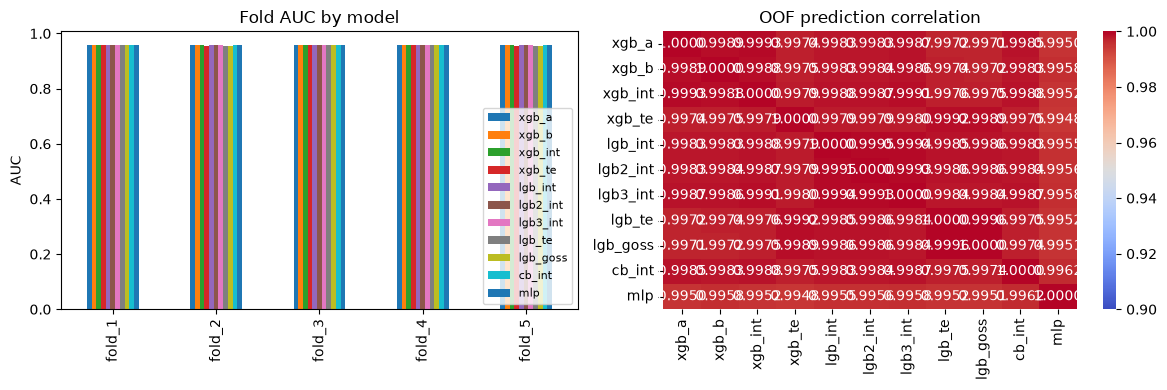

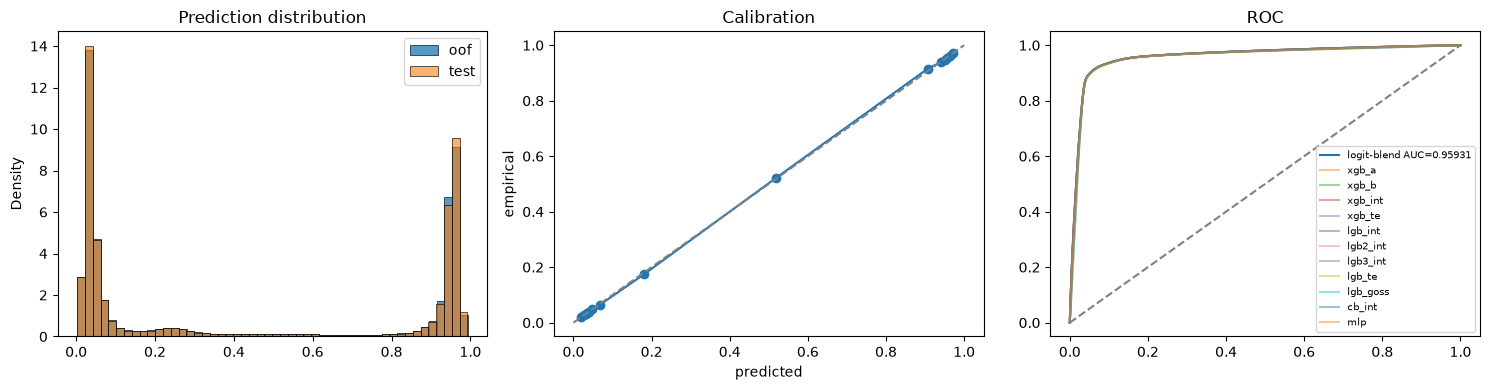

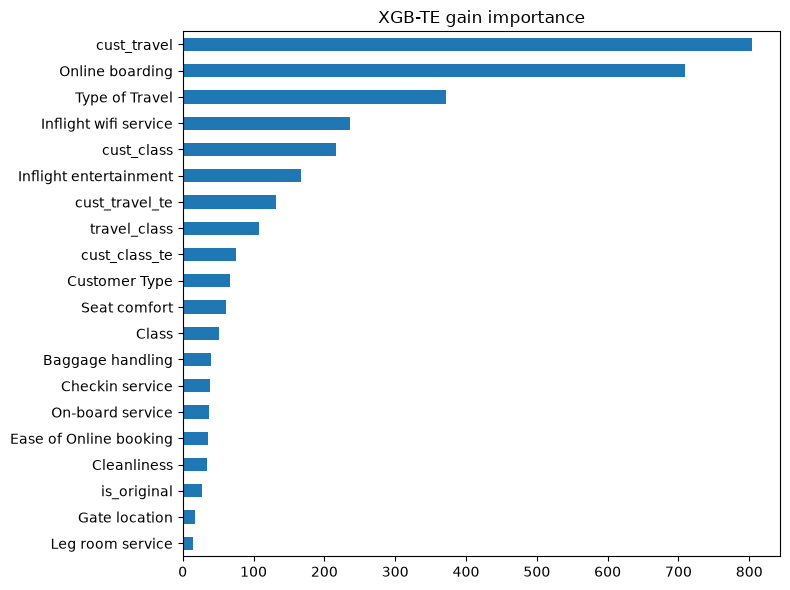

cust_travel               803.211487
Online boarding           709.425781
Type of Travel            371.255219
Inflight wifi service     236.269836
cust_class                216.188065
Inflight entertainment    167.205124
cust_travel_te            131.502640
travel_class              107.278244
cust_class_te              75.024681
Customer Type              67.326965
Seat comfort               60.977116
Class                      51.172283
Baggage handling           40.443207
Checkin service            38.815876
On-board service           37.271168
Ease of Online booking     35.906551
Cleanliness                34.720097
is_original                27.570196
Gate location              17.027691
Leg room service           14.783672
dtype: float64

,id,y,oof,abs_error
211257,211257,1,0.002975,0.997025
447771,447771,1,0.004443,0.995557
87976,87976,1,0.005225,0.994775
127884,127884,1,0.006837,0.993163
171002,171002,1,0.006866,0.993134
218804,218804,1,0.007291,0.992709
87123,87123,1,0.007423,0.992577
656637,656637,1,0.007868,0.992132
245703,245703,1,0.007881,0.992119
149663,149663,1,0.007921,0.992079


logit-blend oof auc: 0.959313


In [9]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve

fold_auc_df = pd.DataFrame(fold_scores)
fold_auc_df.index = [f"fold_{i}" for i in range(1, n_splits + 1)]
display(fold_auc_df)
display(fold_auc_df.agg(["mean", "std"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fold_auc_df.plot(kind="bar", ax=axes[0])
axes[0].set_ylabel("AUC")
axes[0].set_title("Fold AUC by model")
axes[0].legend(loc="lower right", fontsize=8)

corr_preds = pd.DataFrame({name: oof[name] for name in model_names}).corr()
sns.heatmap(corr_preds, annot=True, fmt=".4f", cmap="coolwarm", ax=axes[1], vmin=0.9, vmax=1.0)
axes[1].set_title("OOF prediction correlation")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(oof_pred, bins=50, stat="density", ax=axes[0], color="C0", label="oof")
sns.histplot(test_pred, bins=50, stat="density", ax=axes[0], color="C1", label="test", alpha=0.6)
axes[0].legend()
axes[0].set_title("Prediction distribution")

prob_true, prob_pred = calibration_curve(y, oof_pred, n_bins=15, strategy="quantile")
axes[1].plot(prob_pred, prob_true, marker="o")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("predicted")
axes[1].set_ylabel("empirical")
axes[1].set_title("Calibration")

fpr, tpr, _ = roc_curve(y, oof_pred)
axes[2].plot(fpr, tpr, label=f"logit-blend AUC={oof_auc:.5f}")
for name in model_names:
    fpr_i, tpr_i, _ = roc_curve(y, oof[name])
    axes[2].plot(fpr_i, tpr_i, alpha=0.45, label=name)
axes[2].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[2].set_title("ROC")
axes[2].legend(fontsize=7)
plt.tight_layout()
plt.show()

imp = pd.Series(xgb_models_te[0].get_score(importance_type="gain")).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
imp.head(20).iloc[::-1].plot(kind="barh")
plt.title("XGB-TE gain importance")
plt.tight_layout()
plt.show()
display(imp.head(20))

error_df = train[["id"]].copy()
error_df["y"] = y
error_df["oof"] = oof_pred
error_df["abs_error"] = (error_df["y"] - error_df["oof"]).abs()
display(error_df.sort_values("abs_error", ascending=False).head(10))
print(f"logit-blend oof auc: {oof_auc:.6f}")
